## Modelo de regresión logística

Como se ha señalado anteriormente, la variable respuesta de este modelo será la variable formalidad con niveles 1 para formal y 0 para informal

Es importante aclarar que los resultados que se muestran a continuación se estimaron después de la eliminación de algunas variables que causaban multicolinealidad en el modelo (Ver Prueba de VIF)

In [11]:
variables = [
    'formalidad', 'CLASE', 'Sexo', 'Edad', 'Parentesco con jefe de hogar',
    '¿Usted se reconoce como?', 'Estado civil',
    '¿Afiliado, cotizante o beneficiario de seguridad social en salud?',
    'Mayor nivel educativo alcanzado',
    'Para la ocupación que desempeña, ¿tiene algún tipo de contrato',
    '¿Cuánto tiempo lleva en esta empresa trabajando de forma continua (meses)?',
    'Tipo de ocupación',
    'El mes pasado, ¿recibió pagos por concepto de arriendos o pensiones?',
    '¿Es propietario de una o varias propiedades inmuebles?',
    'Tipo de vivienda', '¿Tiene servicio de energía eléctrica?',
    'Estrato para tarifa', 'Número de hogares en la vivienda',
    'Número de cuartos', 'La vivienda ocupada por este hogar es',
    'Total de personas en el hogar', 'AREA',
    'Meses que estuvo sin empleo entre su trabajo actual y el anterior',
    'Tiempo de desplazamiento hasta su sitio de trabajo'
]




In [16]:
# Filtrar el DataFrame
df_modelo = datos[variables + ['formalidad']].copy()

# Eliminar filas con valores faltantes
df_modelo = df_modelo.dropna()

# Separar variable objetivo y predictoras
y = df_modelo['formalidad'].astype(int)
X = df_modelo.drop(columns='formalidad')

# Convertir variables categóricas a variables dummy
X_dummies = pd.get_dummies(X, drop_first=True)


X_dummies = X_dummies.astype({col: int for col in X_dummies.select_dtypes(bool).columns})
X_dummies = sm.add_constant(X_dummies, has_constant='add')
y = y.iloc[:, 0]   



modelo_logit = sm.Logit(y, X_dummies).fit()
print(modelo_logit.summary())


         Current function value: 0.327940
         Iterations: 35


/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:             formalidad   No. Observations:               353672
Model:                          Logit   Df Residuals:                   353579
Method:                           MLE   Df Model:                           92
Date:                Mon, 20 Oct 2025   Pseudo R-squ.:                  0.5220
Time:                        08:09:02   Log-Likelihood:            -1.1598e+05
converged:                      False   LL-Null:                   -2.4262e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
const                           

De este resumen se puede concluir que el modelo estimado es estadisticamente significativo, dado que el p-valor del chi cuadrado es menor que el nivel de significancia 5%. Este modelo es mejor prediciendo las probabilidades de un empleo formal que uno sin variables. Se observa que la variable sexo, clase y edad tienen un efecto significativo sobre la probabilidad de tener empleo formal. Según los resultados es 1,186 veces más probable conseguir empleo formal si vives en la zona urbana en comparación con trabajadores de zonas rurales. Ser mujer hace menos probable estar en la formalidad, y por cada año de edad se incrementa esta probabilidad en un 0.8%. En cuanto a parentesco con jefe del hogar, ser el nieto, esposo(a) u otro pariente no son significativas dentro del modelo. Al hablar de pertenencia a una comunidad, sólo si la persona se identifica como raizal tiene influencia en la probabilidad de empleo formal.

El estado civil es una variable significativa dentro del modelo; sin embargo, pertenecer a cualquiera de las categorías que no sea estar casado disminuye las probabilidades de tener un empleo formal. Estar afiliado a seguridad social hace más probable tener un empleo formal que aquellos que no tienen afiliación. Como era de esperarse, tener educación superior incrementa las probabilidades de estar empleado formalmente que aquellos que no la tienen. La significancia estadística de tener contrato laboral indica que si el individuo tiene uno, es más probable que tenga empleo formal que aquellos que no. Por otro lado, si lleva muchos meses continuos en el mismo empleo, es más probable que esté formalizado.

Según los resultados si la ocupación que desempeña el individuo es como obrero o empleado del gobierno, las probabilidades de que esté formalizado son mayores que las de aquellos que desempeñan otra actividad. Si ha recibido ingresos por arriendo o pensiones, es más probable tener un empleo formal que aquellos que no. Ser propietario de inmuebles incrementa la razón de probabilidad de tener un empleo formal en un 24.2%. Vivir en apartamento hace más probable tener un empleo formal que vivir en otro tipo de vivienda, y tener energía eléctrica, además de pertenecer a un estrato alto, incrementa el log-odds de tener empleo formal.

Por hogar adicional en una misma vivienda se reduce la probabilidad de que la persona tenga empleo formal en un 23.1%. Por cada cuarto adicional en la vivienda incrementa la posibilidad de que la persona esté formalizada en un 16.1%. Si la vivienda es propia, mayor es la posibilidad de formalidad laboral. Por cada persona adicional en la vivienda, es menos probable que el individuo tenga empleo formal. Vivir en ciudades como Medellín y Manizales hace más probable que ser formal ocurra, y por cada mes que demora una persona en conseguir empleo desde su última experiencia laboral, se disminuye la probabilidad de que tenga un empleo formal en un 0.6%. Por último, por cada minuto adicional que tarde un trabajador en llegar hasta su puesto de trabajo, las probabilidades de que tenga un empleo formal incrementan en un 1.5%

## Prueba estadístico de Wald

In [17]:
wald_test = modelo_logit.tvalues**2  # z^2 = estadístico de Wald
wald_test_df = pd.DataFrame({
    'Variable': modelo_logit.params.index,
    'Wald_Statistic': wald_test,
    'p_value': modelo_logit.pvalues
})
print(wald_test_df.head())


                                                                                             Variable  \
const                                                                                           const   
Edad                                                                                             Edad   
¿Cuánto tiempo lleva en esta empresa trabajando...  ¿Cuánto tiempo lleva en esta empresa trabajand...   
Número de hogares en la vivienda                                     Número de hogares en la vivienda   
Número de cuartos                                                                   Número de cuartos   

                                                    Wald_Statistic  \
const                                                   614.400647   
Edad                                                    185.565584   
¿Cuánto tiempo lleva en esta empresa trabajando...      490.722931   
Número de hogares en la vivienda                         33.444337   
Número de cuartos  

Con un p-valor menor al nivel de significancia, se rechaza la hipótesis nula, y se concluye que al menos uno de los coeficientes es distinto a cero. El modelo ajustado es mejor que uno sin variables

## Prueba de razón de verosimilitud (Likelihood Ratio Test)

In [18]:
import statsmodels.api as sm

# Modelo nulo (solo intercepto)
modelo_nulo = sm.Logit(y, sm.add_constant(pd.DataFrame(index=y.index))).fit(disp=False)
from scipy import stats

# Log-likelihoods
LL_nulo = modelo_nulo.llf
LL_completo = modelo_logit.llf

# Estadístico de prueba
LR_stat = -2 * (LL_nulo - LL_completo)

# Grados de libertad = diferencia en número de parámetros
df = modelo_logit.df_model - modelo_nulo.df_model

# p-valor
p_value = stats.chi2.sf(LR_stat, df)

print(f"Estadístico LR: {LR_stat:.3f}")
print(f"Grados de libertad: {df}")
print(f"p-valor: {p_value:.5f}")


Estadístico LR: 253281.084
Grados de libertad: 92.0
p-valor: 0.00000


Con un p-valor de menor al nivel de significancia, se rechaza la hipotésis nula y se concluye que el modelo más complejo tiene un mejor ajuste que el modelo con solo el intercepto. Por tanto, el modelo estimado provee información útil a la hora de explicar la variabilidad de la variable respuesta.



## Pseudo R² (como McFadden, Cox Snell, Nagelkerke)

Como se pudo observar en la salida, El modelo es bueno explicando aproximadamente el 68% de la variabilidad de la variable formalidad.

## Test de Hosmer y Lemeshow

In [19]:
import pandas as pd
import numpy as np
from scipy import stats

# 1️⃣ Obtener las probabilidades predichas del modelo
predicciones = modelo_logit.predict(X_dummies)

# 2️⃣ Crear un DataFrame con valores observados y predichos
df_hl = pd.DataFrame({'observado': y, 'predicho': predicciones})

# 3️⃣ Dividir las predicciones en 10 grupos (deciles)
df_hl['grupo'] = pd.qcut(df_hl['predicho'], 10, duplicates='drop')

# 4️⃣ Calcular observados y esperados en cada grupo
tabla_hl = df_hl.groupby('grupo').apply(
    lambda g: pd.Series({
        'observados_1': g['observado'].sum(),
        'observados_0': (1 - g['observado']).sum(),
        'esperados_1': g['predicho'].sum(),
        'esperados_0': (1 - g['predicho']).sum()
    })
)

# 5️⃣ Calcular estadístico de Hosmer-Lemeshow
hl_stat = (((tabla_hl['observados_1'] - tabla_hl['esperados_1'])**2) / tabla_hl['esperados_1'] +
           ((tabla_hl['observados_0'] - tabla_hl['esperados_0'])**2) / tabla_hl['esperados_0']).sum()

# 6️⃣ Grados de libertad = número de grupos - 2
df = tabla_hl.shape[0] - 2

# 7️⃣ p-valor
p_value = 1 - stats.chi2.cdf(hl_stat, df)

print(f'Estadístico Hosmer-Lemeshow: {hl_stat:.3f}')
print(f'Grados de libertad: {df}')
print(f'p-valor: {p_value:.5f}')

if p_value > 0.05:
    print("✅ No se rechaza H₀: El modelo se ajusta bien a los datos.")
else:
    print("⚠️ Se rechaza H₀: El modelo no se ajusta bien a los datos.")


Estadístico Hosmer-Lemeshow: 792.622
Grados de libertad: 8
p-valor: 0.00000
⚠️ Se rechaza H₀: El modelo no se ajusta bien a los datos.


/var/folders/83/zn8x0yz50rd407m55phbdf5h0000gp/T/ipykernel_15057/2490104013.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_hl = df_hl.groupby('grupo').apply(
/var/folders/83/zn8x0yz50rd407m55phbdf5h0000gp/T/ipykernel_15057/2490104013.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_hl = df_hl.groupby('grupo').apply(


Como resultado de la aplicación del test de Hosmer se obtiene un p-valor al nivel de significancia del 5%, por lo que se rechaza la hipótesis nula de que el modelo se ajusta bien a los datos. Sin embargo, dicho resultado no es suficiente para descartar el modelo; por el contrario, debe ser contrastado con el hallazgo de otras métricas.Nattino et al. (2020) han señalado anteriormente las limitaciones de esta prueba para el caso de grandes muestras.



## Capacidad predictiva del modelo de regresión logística 

Luego de ajustar el modelo de regresión logística para poder interpretar aquellas variables que más aportan a la probabilidad de tener un empleo formal, se quiere ahora verificar su capacidad predictiva. Se divide el conjunto de datos de la siguiente forma: 80% para training y 20% para test. Posteriormente, se estima el modelo para el conjunto de training y se evalúan sus métricas.

         Current function value: 0.328824
         Iterations: 35


/Applications/miniconda3/envs/ml_venve/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:             formalidad   No. Observations:               282937
Model:                          Logit   Df Residuals:                   282844
Method:                           MLE   Df Model:                           92
Date:                Mon, 20 Oct 2025   Pseudo R-squ.:                  0.5207
Time:                        08:33:54   Log-Likelihood:                -93036.
converged:                      False   LL-Null:                   -1.9410e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
const                           

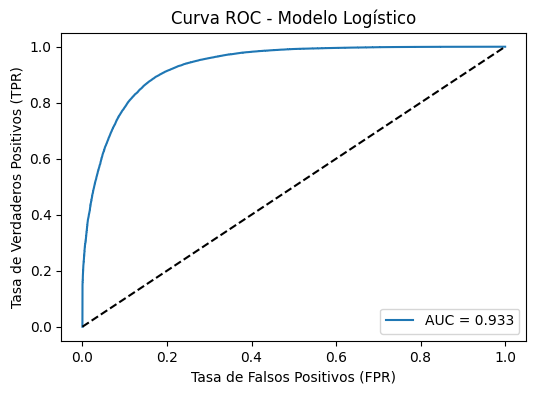

In [22]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Dividir los datos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_dummies, y, test_size=0.2, random_state=42, stratify=y
)
# Ajustar el modelo en los datos de entrenamiento
modelo_train = sm.Logit(y_train, X_train).fit()

# Resumen del modelo
print(modelo_train.summary())

# Predicciones de probabilidad y clasificación
y_pred_prob = modelo_train.predict(X_test)
y_pred = np.where(y_pred_prob >= 0.5, 1, 0)

# Métricas
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nExactitud:", round(accuracy_score(y_test, y_pred), 3))
print("Precisión:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

# Graficar
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Modelo Logístico")
plt.legend()
plt.show()


A partir de las métricas que se muestran en la tabla anterior, con un accuracy de 0.85, el modele es capaz de predecir correctamente casi el 86% de las observaciones. LA precisión muestra que cada vez que el modelo predice formal, lo hace correctamente el 82% de las veces. Con un F1 score de 83% el modelo parecer ser equilibrado sin favorecer falsos positivos o falsos negativos. 
El valor del área bajo la curva es de 0.93. Cifra cercana a 1 que da luces sobre la capacidad predictiva el modelo. Este es capaz de discriminar correct